<a href="https://colab.research.google.com/github/AshithaVenu/Biomass-estimation-using-optical-and-microwave-satellite-remote-sensing/blob/main/timeseries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
mport xarray as xr
import rioxarray
import geopandas as gpd
from shapely.geometry import box

# Define paths
netcdf_file = "path/to/your/precipitation.nc"  # Replace with your NetCDF file path
output_path = "path/to/clipped_precipitation.nc"  # Output file path

# Define the bounding box coordinates (in meters, sinusoidal projection)
left = 1111950519700  # Left extent
right = 2223901039372  # Right extent
bottom = 4447802078628  # Bottom extent
top = 5559752598300  # Top extent

# Define the sinusoidal projection CRS
sinusoidal_crs = "+proj=sinu +lon_0=0 +x_0=0 +y_0=0 +ellps=WGS84 +datum=WGS84 +units=m +no_defs"

# Create a bounding box geometry
bbox = box(left, bottom, right, top)
gdf = gpd.GeoDataFrame(geometry=[bbox], crs=sinusoidal_crs)

SyntaxError: invalid syntax (<ipython-input-1-7693a6e141f8>, line 1)

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Install required libraries
!pip install xarray rioxarray matplotlib cartopy

# Import libraries
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Define path
netcdf_path = "/content/drive/My Drive/Europe_and_Siberia/clipped_precipitation.nc"

# Load precipitation data
try:
    ds = xr.open_dataset(netcdf_path)
    precip = ds['tp']  # Total precipitation
    print("Precipitation data loaded. Dimensions:", precip.dims)
    print("Precipitation time range:", precip.time.values.min(), "to", precip.time.values.max())
    print("Precipitation attributes:", precip.attrs)
    print("Precipitation NaN percentage:", np.isnan(precip.values).mean() * 100, "%")
except Exception as e:
    print(f"Error loading precipitation data: {e}")
    raise

Mounted at /content/drive
Precipitation data loaded. Dimensions: ('time', 'latitude', 'longitude')
Precipitation time range: 2000-01-01T00:00:00.000000000 to 2021-12-01T00:00:00.000000000
Precipitation attributes: {'long_name': 'Total precipitation', 'units': 'm', 'grid_mapping': 'sinusoidal'}
Precipitation NaN percentage: 30.01666666666667 %


/usr/local/lib/python3.11/dist-packages/xarray/groupers.py:490: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(
Exception ignored in: <function CachingFileManager.__del__ at 0x7ed479750720>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/xarray/backends/file_manager.py", line 250, in __del__
  File "/usr/local/lib/python3.11/dist-packages/xarray/backends/file_manager.py", line 234, in close
  File "/usr/local/lib/python3.11/dist-packages/scipy/io/_netcdf.py", line 316, in close
OSError: [Errno 107] Transport endpoint is not connected


Selected precipitation years: [2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014
 2015 2016 2017 2018 2019 2020 2021]
Precip_time NaN percentage: 30.01666666666667 %
Precip_annual_mm shape: (21, 100, 180)
Precip_annual_mm NaN percentage: 0.0 %
Latitude range: 40.0 to 49.9
Longitude range: 13.1 to 31.0

=== Precipitation Values (mm/year) ===

Annual mean precipitation (mm/year) across all grid points:
Year 2001: 615.78 mm/year
Year 2002: 619.09 mm/year
Year 2003: 501.93 mm/year
Year 2004: 632.95 mm/year
Year 2005: 697.98 mm/year
Year 2006: 581.19 mm/year
Year 2007: 586.38 mm/year
Year 2008: 565.18 mm/year
Year 2009: 613.49 mm/year
Year 2010: 751.29 mm/year
Year 2011: 436.71 mm/year
Year 2012: 549.72 mm/year
Year 2013: 608.23 mm/year
Year 2014: 705.36 mm/year
Year 2015: 538.91 mm/year
Year 2016: 640.67 mm/year
Year 2017: 579.48 mm/year
Year 2018: 616.51 mm/year
Year 2019: 567.75 mm/year
Year 2020: 579.04 mm/year
Year 2021: 619.30 mm/year

Annual precipitation (mm/year

/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


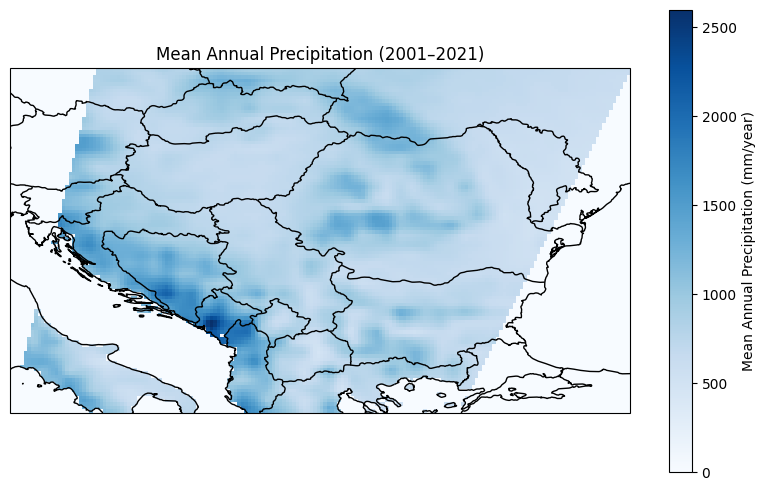

In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

try:
    # Verify precip DataArray
    if 'precip' not in globals():
        raise ValueError("Precipitation DataArray 'precip' not found. Ensure the dataset is loaded correctly.")

    # Check dimensions
    required_dims = {'time', 'latitude', 'longitude'}
    if not all(dim in precip.dims for dim in required_dims):
        raise ValueError(f"Expected dimensions {required_dims}, but found {precip.dims}")

    # Step 1: Select time range (2001–2021)
    precip_time = precip.sel(time=slice('2001-01-01', '2021-12-31'))
    if precip_time.time.size == 0:
        raise ValueError("No data found in the time range 2001-2021. Check the time coordinate.")

    # Verify selected years
    years = np.unique(precip_time.time.dt.year.values)
    print("Selected precipitation years:", years)
    print("Precip_time NaN percentage:", np.isnan(precip_time.values).mean() * 100, "%")

    # Step 2: Multiply monthly average daily precip (m/day) by days in each month to get monthly totals (m/month)
    days_in_month = precip_time.time.dt.days_in_month
    precip_monthly_total_m = precip_time * days_in_month

    # Step 3: Sum monthly totals per year to get annual totals (m/year)
    precip_annual_m = precip_monthly_total_m.resample(time='A').sum(dim='time')

    # Step 4: Convert m/year to mm/year
    precip_annual_mm = precip_annual_m * 1000  # 1 m = 1000 mm

    # Step 5: Diagnostics
    print("Precip_annual_mm shape:", precip_annual_mm.shape)
    print("Precip_annual_mm NaN percentage:", np.isnan(precip_annual_mm.values).mean() * 100, "%")
    print("Latitude range:", precip_annual_mm.latitude.values.min(), "to", precip_annual_mm.latitude.values.max())
    print("Longitude range:", precip_annual_mm.longitude.values.min(), "to", precip_annual_mm.longitude.values.max())

    # Step 6: Display precipitation values after conversion
    print("\n=== Precipitation Values (mm/year) ===")

    # 6.1: Summary statistics (mean across spatial dimensions for each year)
    annual_mean = precip_annual_mm.mean(dim=['latitude', 'longitude'])
    print("\nAnnual mean precipitation (mm/year) across all grid points:")
    for year, value in zip(years, annual_mean.values):
        print(f"Year {int(year)}: {value:.2f} mm/year")

    # 6.2: Example values for a specific location (e.g., near the center of the domain)
    lat_center = (precip_annual_mm.latitude.values.min() + precip_annual_mm.latitude.values.max()) / 2
    lon_center = (precip_annual_mm.longitude.values.min() + precip_annual_mm.longitude.values.max()) / 2
    precip_point = precip_annual_mm.sel(latitude=lat_center, longitude=lon_center, method='nearest')
    print(f"\nAnnual precipitation (mm/year) at location (lat={precip_point.latitude.values:.2f}, lon={precip_point.longitude.values:.2f}):")
    for year, value in zip(years, precip_point.values):
        print(f"Year {int(year)}: {value:.2f} mm/year")

    # 6.3: Optional map of mean annual precipitation (2001–2021)
    plt.figure(figsize=(10, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    precip_annual_mm.mean(dim='time').plot(ax=ax, transform=ccrs.PlateCarree(), cmap='Blues', cbar_kwargs={'label': 'Mean Annual Precipitation (mm/year)'})
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS)
    plt.title("Mean Annual Precipitation (2001–2021)")
    plt.show()

except Exception as e:
    print(f"Error during precipitation processing: {e}")
    print("Precipitation time range:", precip.time.values.min(), "to", precip.time.values.max())
    raise


In [ ]:
# Set CRS (assume WGS84 based on latitude/longitude)
precip_annual = precip_annual.rio.write_crs("EPSG:4326")
print("Precip_annual CRS:", precip_annual.rio.crs)

# Compute mean annual precipitation for spatial map
precip_mean = precip_annual.mean(dim='time')
print("Precip_mean shape:", precip_mean.shape)
print("Precip_mean NaN percentage:", np.isnan(precip_mean.values).mean() * 100, "%")

# Compute spatially averaged precipitation for time series
precip_spatial_mean = precip_annual.mean(dim=['latitude', 'longitude'])
print("Precip_spatial_mean shape:", precip_spatial_mean.shape)

Precip_annual CRS: EPSG:4326
Precip_mean shape: (100, 180)
Precip_mean NaN percentage: 0.0 %
Precip_spatial_mean shape: (21,)


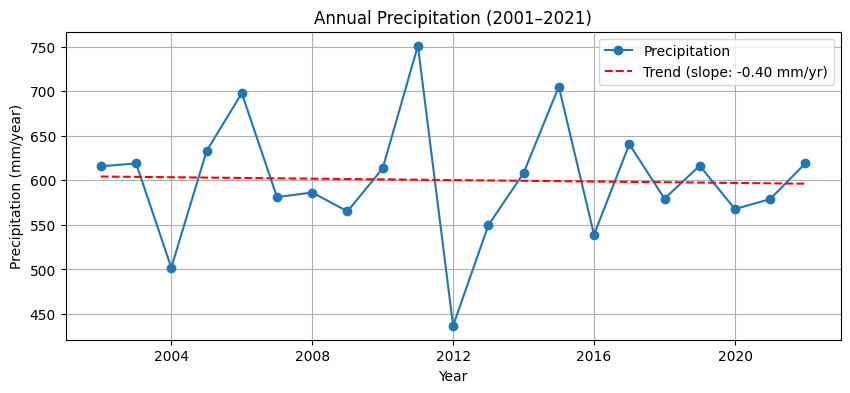

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Compute spatially averaged precipitation (mean over latitude and longitude)
precip_spatial_mean = precip_annual_mm.mean(dim=['latitude', 'longitude'])

# Plot 2: Time series of spatially averaged precipitation with trendline
plt.figure(figsize=(10, 4))

# Plot the data points with markers
precip_spatial_mean.plot.line(x='time', marker='o', label='Precipitation')

# Calculate and plot the trendline
# Extract time (years) and precipitation values
time = precip_spatial_mean['time'].values
precip = precip_spatial_mean.values
# Convert time to numeric values (years since 2001) for regression
time_numeric = np.arange(len(time))
# Fit a linear trend (degree 1 polynomial)
coeffs = np.polyfit(time_numeric, precip, 1)
trendline = np.polyval(coeffs, time_numeric)
# Plot the trendline
plt.plot(time, trendline, 'r--', label=f'Trend (slope: {coeffs[0]:.2f} mm/yr)')

# Customize the plot
plt.title('Annual Precipitation (2001–2021)')
plt.xlabel('Year')
plt.ylabel('Precipitation (mm/year)')
plt.grid(True)
plt.legend()  # Add legend to show data and trendline
plt.savefig('precip_time_series_with_trend.png')
plt.show()